# Titanic Survival Prediction
## Step 1: Import Libraries

In this step we import the Python libraries required for data analysis,
visualization, and machine learning.

- NumPy: numerical computations
- Pandas: data manipulation
- Matplotlib & Seaborn: data visualization

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


## Step 2: Load the Titanic Dataset

The Titanic competition provides two datasets:

• train.csv → contains passenger data and survival outcome  
• test.csv → contains passenger data but no survival labels  

The goal is to train a machine learning model using the training data
and predict survival for passengers in the test dataset.

## Step 2: Load the Titanic Dataset

In this step, we load the Titanic dataset provided by Kaggle.
The dataset is divided into two files:

• train.csv – contains passenger information and survival outcomes  
• test.csv – contains passenger information but no survival labels

The training dataset will be used to train the machine learning model.

In [2]:
# Load the training dataset
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

# Load the test dataset
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")



## Step 3: Inspect the Data

Before training a machine learning model, it is important to understand
the structure of the dataset.

This step helps us identify:
• number of observations
• feature types
• missing values

## Step 3: Inspect the Dataset

Using train.info(), we examine the structure of the dataset.

The training dataset contains 891 passengers and 12 features.
Some variables contain missing values, particularly Age, Cabin,
and Embarked.

These missing values must be handled before training a machine learning model.

In [3]:
# Display dataset information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step 4: Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us discover patterns in the data.

In this step, we explore patterns in the dataset to understand
which factors may influence passenger survival.

We begin by visualizing the distribution of survivors and non-survivors.


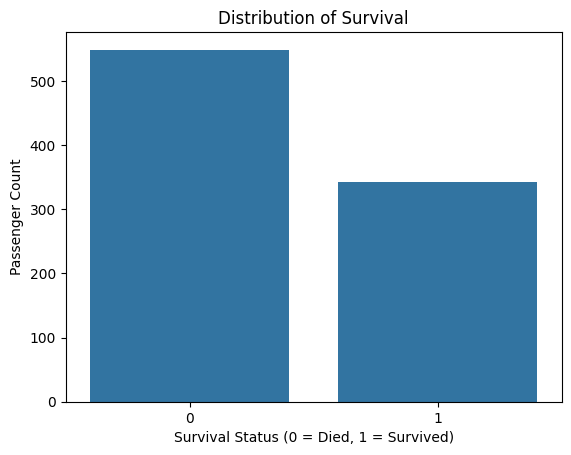

In [4]:
# Survival count
sns.countplot(x="Survived", data=train)
plt.title("Distribution of Survival")
plt.xlabel("Survival Status (0 = Died, 1 = Survived)")
plt.ylabel("Passenger Count")

plt.show()

### Observations

The survival distribution shows that more passengers died than survived.
Approximately 549 passengers did not survive, while 342 survived.

This indicates that the dataset is slightly imbalanced, which is common
in real-world classification problems.


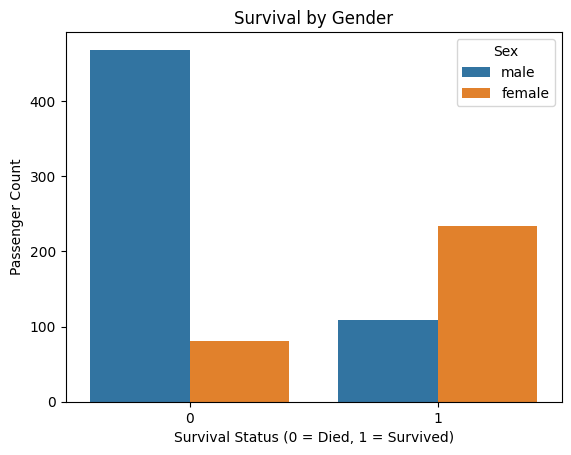

In [5]:
# -------------------------------------------------------------
# Step 4.2: Analyze Survival by Gender
# -------------------------------------------------------------
# In this step, we examine how survival rates differ between
# male and female passengers. This helps us determine whether
# gender is an important factor influencing survival.

# Create a count plot showing survival outcomes grouped by gender
sns.countplot(x="Survived", hue="Sex", data=train)

# Add a title to the graph
plt.title("Survival by Gender")

# Label the x-axis (0 = died, 1 = survived)
plt.xlabel("Survival Status (0 = Died, 1 = Survived)")

# Label the y-axis showing the number of passengers
plt.ylabel("Passenger Count")

# Display the graph
plt.show()

### Observations

The survival rates differ significantly between male and female passengers.
Female passengers were much more likely to survive compared to male passengers.

This pattern reflects the historical evacuation policy of "women and children first".
Therefore, gender is expected to be an important feature for the machine learning model.

### Why This Step Matters

Analyzing survival by gender helps identify important patterns in the dataset before building a machine learning model. Exploratory Data Analysis (EDA) allows us to understand which variables may strongly influence the prediction target.

In this case, the visualization shows a clear difference in survival rates between male and female passengers. Female passengers appear to have survived at a much higher rate than male passengers.

This suggests that **gender is a highly informative feature** that the machine learning model can use to improve prediction accuracy.

## Survival by Passenger Class

In this step, we analyze how survival rates vary across passenger classes.
The Titanic had three ticket classes:

- 1st Class: Wealthiest passengers
- 2nd Class: Middle class passengers
- 3rd Class: Lower class passengers

By visualizing survival outcomes by class, we can determine whether socioeconomic status influenced survival probability.

| Color  | Class     |
| ------ | --------- |
| Green  | 1st class |
| Yellow | 2nd class |
| Red    | 3rd class |


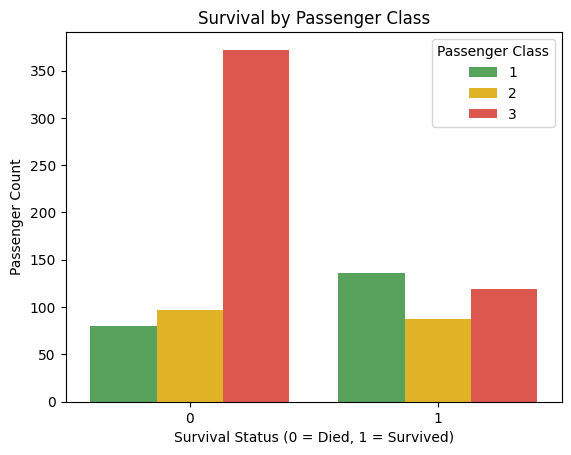

In [6]:
# -------------------------------------------------------------
# Step 4.3: Analyze Survival by Passenger Class
# -------------------------------------------------------------
# This visualization compares survival outcomes across the
# three passenger classes (1st, 2nd, and 3rd class).

# Create the count plot grouped by passenger class
sns.countplot(x="Survived", hue="Pclass", data=train,
              palette=["#4CAF50", "#FFC107", "#F44336"])

# Add title
plt.title("Survival by Passenger Class")

# Label axes
plt.xlabel("Survival Status (0 = Died, 1 = Survived)")
plt.ylabel("Passenger Count")

# Add legend to explain the colors
plt.legend(title="Passenger Class")

# Display the plot
plt.show()

### Observations

The chart compares survival outcomes across the three passenger classes.
Passengers in first class show the highest survival counts, while passengers
in third class experienced the lowest survival rates.

This suggests that socioeconomic status may have influenced survival
probability during the evacuation.

## Survival by Age

In this step, we examine how passenger age relates to survival.

By comparing the age distribution of survivors and non-survivors,
we can identify whether children or younger passengers had a higher
chance of surviving the Titanic disaster.

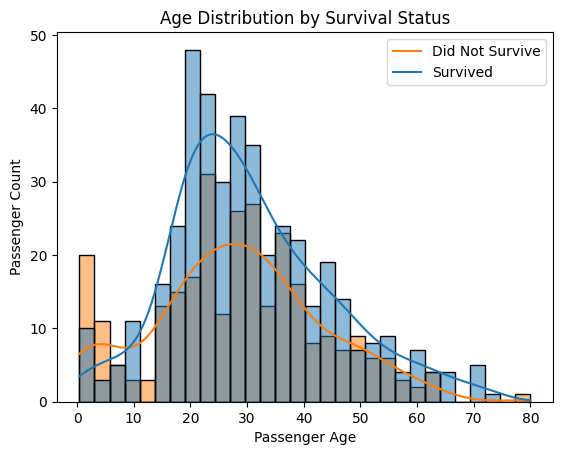

In [7]:
# -------------------------------------------------------------
# Step 4.4: Analyze Survival by Age
# -------------------------------------------------------------
# This visualization compares the age distribution of passengers
# who survived versus those who did not survive.

# Create a histogram of passenger ages grouped by survival status
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True)

# Add title
plt.title("Age Distribution by Survival Status")

# Label axes
plt.xlabel("Passenger Age")
plt.ylabel("Passenger Count")

# Add legend labels
plt.legend(["Did Not Survive", "Survived"])

# Display the plot
plt.show()

### Observations

The age distribution shows that most passengers were between
20 and 35 years old. Younger passengers, particularly children,
appear to have slightly higher survival rates.

This pattern reflects the historical evacuation policy of
"women and children first." However, the overlap between survivors
and non-survivors suggests that age alone is not the strongest
predictor of survival.

Other factors such as gender and passenger class likely played
a larger role in determining survival outcomes.

## What We Have Discovered So Far

Through Exploratory Data Analysis, we identified several important features:

Sex → strong survival predictor
Passenger Class → strong survival predictor
Age → possible survival influence

## Step 5: Data Cleaning

Before training a machine learning model, we must handle missing values
in the dataset.

From our earlier inspection we found missing values in:
- Age
- Embarked
- Cabin

In this step we will fill missing values for Age and Embarked.
The Cabin column contains too many missing values and will be removed.

In [8]:
# -------------------------------------------------------------
# Step 5.1: Fill Missing Age Values
# -------------------------------------------------------------
# Replace missing ages with the median age

train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

In [9]:
# -------------------------------------------------------------
# Step 5.2: Fill Missing Embarked Values
# -------------------------------------------------------------
# Replace missing Embarked values with the most frequent value

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

In [10]:
# -------------------------------------------------------------
# Step 5.3: Remove Cabin Column
# -------------------------------------------------------------
# Cabin has too many missing values to be useful


train.drop(columns=["Cabin"], inplace=True, errors="ignore")
test.drop(columns=["Cabin"], inplace=True, errors="ignore")

print(train.columns)
print(test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked'],
      dtype='object')


### Handling Missing Embarked Values

The Embarked column contains two missing values. Since this column
represents the port where passengers boarded the Titanic, the missing
values were replaced with the most frequent port in the dataset.

Using the most common category helps preserve the distribution of
the data without introducing bias.

## Step 6: Convert Categorical Features

Machine learning models require numerical input. In this step,
categorical variables such as Sex and Embarked are converted
into numeric values so they can be used for model training.

In [11]:
# Step 6: Convert categorical features safely

import pandas as pd

# Step 6: Convert categorical features

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
test["Embarked"] = test["Embarked"].fillna(test["Embarked"].mode()[0])

train["Sex"] = train["Sex"].replace({"male": 0, "female": 1})
test["Sex"] = test["Sex"].replace({"male": 0, "female": 1})

train["Embarked"] = train["Embarked"].replace({"S": 0, "C": 1, "Q": 2})
test["Embarked"] = test["Embarked"].replace({"S": 0, "C": 1, "Q": 2})

print(train[["Sex", "Embarked"]].head())
print(test[["Sex", "Embarked"]].head())

   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0
   Sex  Embarked
0    0         2
1    1         0
2    0         2
3    0         0
4    1         0


/tmp/ipykernel_16/3062082705.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train["Sex"] = train["Sex"].replace({"male": 0, "female": 1})
/tmp/ipykernel_16/3062082705.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test["Sex"] = test["Sex"].replace({"male": 0, "female": 1})
/tmp/ipykernel_16/3062082705.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavi

In [12]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


## Step 7: Define Features and Target

In this step, the input features and target variable are defined for model training. The feature matrix `X` contains the selected passenger attributes used to predict survival, while the target vector `y` contains the actual survival outcomes from the training dataset. This separates the independent variables from the dependent variable and prepares the data for the modeling process.

In [13]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = train[features]
y = train["Survived"]
X_test_final = test[features]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())
print(y.head())

X shape: (891, 7)
y shape: (891,)
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    0  22.0      1      0   7.2500         0
1       1    1  38.0      1      0  71.2833         1
2       3    1  26.0      0      0   7.9250         0
3       1    1  35.0      1      0  53.1000         0
4       3    0  35.0      0      0   8.0500         0
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


## Step 8: Split Training and Validation Data

In this step, the dataset is divided into training and validation sets. The training set is used to teach the model survival patterns, while the validation set is used to test how well the model performs on unseen data. This helps evaluate model performance before generating final predictions and reduces the risk of overfitting.

In [14]:
# Step 8: Split training and validation data

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 7)
X_valid shape: (179, 7)
y_train shape: (712,)
y_valid shape: (179,)


## Step 9: Train Baseline Model

In this step, a baseline Random Forest Classifier is trained using the training data. The model learns patterns from the selected passenger features and uses those relationships to classify whether a passenger is likely to survive. This serves as the initial model for performance evaluation and later improvement.

In [15]:
# Step 9: Train the Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## Step 10: Evaluate Model Performance

In this step, the trained model is evaluated on the validation dataset using classification metrics. Accuracy measures overall correctness, precision measures how often positive predictions are correct, recall measures how many actual positives are identified, and F1 score provides a balance between precision and recall. This step is important because it gives a clearer understanding of model performance beyond a single accuracy score.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = rf_model.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred))
print("Recall:", recall_score(y_valid, y_pred))
print("F1 Score:", f1_score(y_valid, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("\nClassification Report:\n", classification_report(y_valid, y_pred))

Accuracy: 0.8156424581005587
Precision: 0.78125
Recall: 0.7246376811594203
F1 Score: 0.7518796992481203

Confusion Matrix:
 [[96 14]
 [19 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



What this means:

Accuracy = 81.56%
The model predicted the correct outcome for about 82% of passengers in the validation set.

Precision = 78.13%
When the model predicted that a passenger survived, it was correct about 78% of the time.

Recall = 72.46%
The model identified about 72% of the actual survivors.

F1 Score = 75.19%
This is the balance between precision and recall, and it shows fairly solid classification performance.

Confusion matrix interpretation
[[96 14]
 [19 50]]

That means:

96 true negatives → correctly predicted did not survive
14 false positives → predicted survived, but actually did not
19 false negatives → predicted did not survive, but actually survived
50 true positives → correctly predicted survived 

### Summary

### Feature Encoding

Categorical variables such as Sex and Embarked were converted into
numeric values so they can be processed by machine learning algorithms.

Sex was encoded as:
0 = male
1 = female

Embarked was encoded as:
0 = Southampton
1 = Cherbourg
2 = Queenstown